In [1]:
import torch
import numpy as np
import scanpy as sc
import pandas as pd
import numpy as np, torch, scipy.sparse as sp
import torch
import scvi

import sys 
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
from model.lr_dec import *

In [2]:
base_dir = 'data/mouse_brain/processed'

adata = sc.read_h5ad(f'{base_dir}/mouse.h5ad')

adata.obs_names_make_unique()

In [3]:
adata.obs["annotation"] = adata.obs["annotation"].astype("category")
adata.obs["annotation"] = adata.obs["annotation"].cat.remove_unused_categories()

print(adata.obs["annotation"].unique())

lr_pairs = pd.read_csv("data/lrpairs/mouse/LR_pairs.csv")
print(lr_pairs.iloc[:1, 2:4])
ligand_list = lr_pairs['ligand'].unique()
receptor_list = lr_pairs['receptor'].unique()

gene_idx = pd.Index(adata.var_names.astype(str))
ligand   = gene_idx.intersection(pd.Index(ligand_list))
receptor = gene_idx.intersection(pd.Index(receptor_list))
ligand_df   = pd.DataFrame(ligand.sort_values(), columns=["ligand"])
receptor_df = pd.DataFrame(receptor.sort_values(), columns=["receptor"])
print("ligand gene num: ", len(ligand))
print("receptor gene num: ", len(receptor))
feat = adata.var_names.astype(str).values

X = adata.layers['counts']
X = X.toarray() if sp.issparse(X) else X

expr = pd.DataFrame(X, index=adata.obs_names, columns=feat)

expr_L = expr.loc[:, expr.columns.intersection(ligand)]
expr_R = expr.loc[:, expr.columns.intersection(receptor)]

print(expr_L.iloc[:2, :2])
print(expr_R.iloc[:2, :2])

['purkinje layer', 'granular layer', 'molecular layer', 'white matter']
Categories (4, object): ['granular layer', 'molecular layer', 'purkinje layer', 'white matter']
  ligand   receptor
0  Tgfb1  TGFbR1_R2
ligand gene num:  378
receptor gene num:  295
         Col9a1  Sema4c
268_226     0.0     0.0
217_190     0.0     0.0
         Npbwr1  Oprk1
268_226     0.0    0.0
217_190     0.0    0.0


In [4]:
model_dir = "outputs/mouse_brain/ckpt/scvi/scanvi"
model = scvi.model.SCANVI.load(model_dir, adata)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/project/src/mouse_ckpt copy/scvi/scanvi/model.pt already downloaded                     


## TRAIN DECORDER

In [5]:
OUT_DIR = "outputs/mouse_brain/ckpt/exp_decoder"
SAMPLE_IDS = ["T167", "T168", "T169", "T170", "T171"]

genes = sorted(set(map(str, ligand)) | set(map(str, receptor)))

results = train_count_decoder_pairs(
    adata=adata,
    model=model,
    genes=genes,
    sample_ids=SAMPLE_IDS,
    sample_key="sample",
    out_dir=OUT_DIR,
    sample_prefix="decoder_counts_pair",
    layer_counts="counts",
    skip_if_exists=False,
    seed=2025,
    test_size=0.2,
    batch_size=512,
    epochs=200,
    patience=10,
    lr=1e-3,
    device="cuda:0",
)
for r in results:
    print(r)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


T167_T168 ep 088/200:  44%|███▉     | 87/200 [00:27<00:35,  3.18it/s, tr=0.0419 va=0.0421]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


T168_T169 ep 079/200:  39%|███▌     | 78/200 [00:37<00:58,  2.07it/s, tr=0.0477 va=0.0473]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


T169_T170 ep 094/200:  46%|████▏    | 93/200 [00:54<01:02,  1.72it/s, tr=0.0466 va=0.0469]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


T170_T171 ep 074/200:  36%|███▎     | 73/200 [00:50<01:27,  1.45it/s, tr=0.0400 va=0.0402]

DecoderTrainResult(pair_id='T167_T168', n_cells=37692, n_genes=637, best_val=0.042112282687130534, decoder_ckpt_path='/home/zhouyj/project/src/mouse_ckpt copy/exp_decoder/decoder_counts_pair_T167_T168.pt', decoder_stat_path='/home/zhouyj/project/src/mouse_ckpt copy/exp_decoder/decoder_counts_pair_T167_T168.json')
DecoderTrainResult(pair_id='T168_T169', n_cells=57408, n_genes=637, best_val=0.047309159991257906, decoder_ckpt_path='/home/zhouyj/project/src/mouse_ckpt copy/exp_decoder/decoder_counts_pair_T168_T169.pt', decoder_stat_path='/home/zhouyj/project/src/mouse_ckpt copy/exp_decoder/decoder_counts_pair_T168_T169.json')
DecoderTrainResult(pair_id='T169_T170', n_cells=68795, n_genes=637, best_val=0.04694020735895802, decoder_ckpt_path='/home/zhouyj/project/src/mouse_ckpt copy/exp_decoder/decoder_counts_pair_T169_T170.pt', decoder_stat_path='/home/zhouyj/project/src/mouse_ckpt copy/exp_decoder/decoder_counts_pair_T169_T170.json')
DecoderTrainResult(pair_id='T170_T171', n_cells=80973, n

In [6]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# =====  decoder (musttraining)=====
class NoisyCountDecoder(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, h=(256, 256),
                 dropout=0.2, noise_in=0.0, noise_h=0.0):
        super().__init__()
        self.noise_in = float(noise_in)
        self.noise_h  = float(noise_h)
        self.p_drop   = float(dropout)

        layers = []
        dims = [in_dim] + list(h)
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i+1]), nn.LayerNorm(dims[i+1])]
        self.backbone = nn.ModuleList(layers)

        self.head = nn.Linear(dims[-1], out_dim)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    @staticmethod
    def _jitter(x, scale: float, enabled: bool):
        if scale <= 0 or (not enabled):
            return x
        s = x.detach().std(dim=0, keepdim=True).clamp_(min=1e-6)
        return x + torch.randn_like(x) * (scale * s)

    def forward(self, z, *, sample: bool = False):
        enabled = sample or self.training
        h = self._jitter(z, self.noise_in, enabled)

        it = iter(self.backbone)
        for lin, ln in zip(it, it):
            h = lin(h)
            h = ln(h)
            h = F.silu(h)
            h = self._jitter(h, self.noise_h, enabled)
            h = F.dropout(h, p=self.p_drop, training=enabled)

        return self.head(h)


def load_count_decoder(ckpt_path: str, stat_path: str, device: str = "cuda:0",
                       h=(256,256), dropout=0.2):
    """
    :decoder, genes(list), meta(dict)
    """
    with open(stat_path, "r") as f:
        meta = json.load(f)

    in_dim = int(meta["in_dim"])
    out_dim = int(meta["out_dim"])
    genes = list(map(str, meta["genes"]))

    dec = NoisyCountDecoder(
        in_dim=in_dim, out_dim=out_dim, h=h,
        dropout=float(dropout),
        noise_in=0.0, noise_h=0.0,   # 
    ).to(device)

    sd = torch.load(ckpt_path, map_location=device)
    dec.load_state_dict(sd, strict=True)
    dec.eval()
    return dec, genes, meta


@torch.no_grad()
def decode_counts_from_latent(
    Z: np.ndarray,
    decoder: nn.Module,
    batch_size: int = 4096,
    device: str = "cuda:0",
    clamp_nonneg: bool = True,
) -> np.ndarray:
    """
    Z: (N, in_dim) numpy
    return: Yhat (N, out_dim) numpy
    """
    Zt = torch.from_numpy(Z.astype(np.float32, copy=False))
    outs = []
    for i in range(0, Zt.shape[0], batch_size):
        zb = Zt[i:i+batch_size].to(device, non_blocking=True)
        pred = decoder(zb)
        if clamp_nonneg:
            pred = pred.clamp_min_(0.0)   # raw counts 
        outs.append(pred.detach().cpu())
    return torch.cat(outs, dim=0).numpy()


def decode_adata_to_obsm(
    adata,
    scvi_model,
    decoder,
    *,
    out_key: str = "counts_hat_genes",
    out_genes_key: str = "counts_hat_genes_var",
    latent_key: str = "X_scanVI",      # " X_scanVI "
    batch_size: int = 4096,
    device: str = "cuda:0",
    clamp_nonneg: bool = True,
):
    """
    :
      adata.obsm[out_key] = (N, G)
      adata.uns[out_genes_key] = genes list
    """
    if latent_key in adata.obsm:
        Z = np.asarray(adata.obsm[latent_key], dtype=np.float32)
    else:
        # fallback:missing X_scanVI  scvi/scanvi 
        Z = scvi_model.get_latent_representation(adata=adata).astype(np.float32, copy=False)

    Yhat = decode_counts_from_latent(
        Z, decoder, batch_size=batch_size, device=device, clamp_nonneg=clamp_nonneg
    )
    adata.obsm[out_key] = Yhat
    # genes : load_count_decoder 
    # here genes,
    return adata

In [7]:
import matplotlib.pyplot as plt
import scipy.sparse as sp

def _get_xy(adata, x="cx", y="cy", obsm_key=None):
    if obsm_key is not None:
        xy = np.asarray(adata.obsm[obsm_key])
        return xy[:, 0], xy[:, 1]
    return np.asarray(adata.obs[x]), np.asarray(adata.obs[y])

def _get_true_gene_counts(adata, gene: str, layer: str = "counts") -> np.ndarray:
    gi = int(np.where(adata.var_names == gene)[0][0])
    X = adata.layers[layer]
    if sp.issparse(X):
        v = X[:, gi].toarray().ravel()
    else:
        v = np.asarray(X)[:, gi].ravel()
    return v.astype(np.float32, copy=False)

def _get_pred_gene_counts(adata, gene: str, pred_obsm: str, pred_genes: list) -> np.ndarray:
    j = int(pred_genes.index(gene))
    return np.asarray(adata.obsm[pred_obsm])[:, j].astype(np.float32, copy=False)

def plot_true_vs_pred_spatial(
    adata,
    gene: str,
    *,
    true_layer: str = "counts",
    pred_obsm: str = "counts_hat_genes",
    pred_genes: list,
    x: str = "cx",
    y: str = "cy",
    obsm_xy: str = None,      # coordinates adata.obsm["spatial"],here "spatial"
    s: float = 3.0,
    log1p: bool = True,
    same_scale: bool = True,
    invert_y: bool = True,
):
    x0, y0 = _get_xy(adata, x=x, y=y, obsm_key=obsm_xy)
    v_true = _get_true_gene_counts(adata, gene, layer=true_layer)
    v_pred = _get_pred_gene_counts(adata, gene, pred_obsm=pred_obsm, pred_genes=pred_genes)

    if log1p:
        v_true = np.log1p(v_true)
        v_pred = np.log1p(v_pred)

    if same_scale:
        vmin = float(min(v_true.min(), v_pred.min()))
        vmax = float(max(v_true.max(), v_pred.max()))
    else:
        vmin = vmax = None

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=140)
    ax = axes[0]
    im0 = ax.scatter(x0, y0, c=v_true, s=s, vmin=vmin, vmax=vmax)
    ax.set_title(f"{gene} true ({true_layer})" + (" log1p" if log1p else ""))
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    if invert_y: ax.invert_yaxis()
    plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1]
    im1 = ax.scatter(x0, y0, c=v_pred, s=s, vmin=vmin, vmax=vmax)
    ax.set_title(f"{gene} decoded ({pred_obsm})" + (" log1p" if log1p else ""))
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    if invert_y: ax.invert_yaxis()
    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    return fig, (v_true, v_pred)

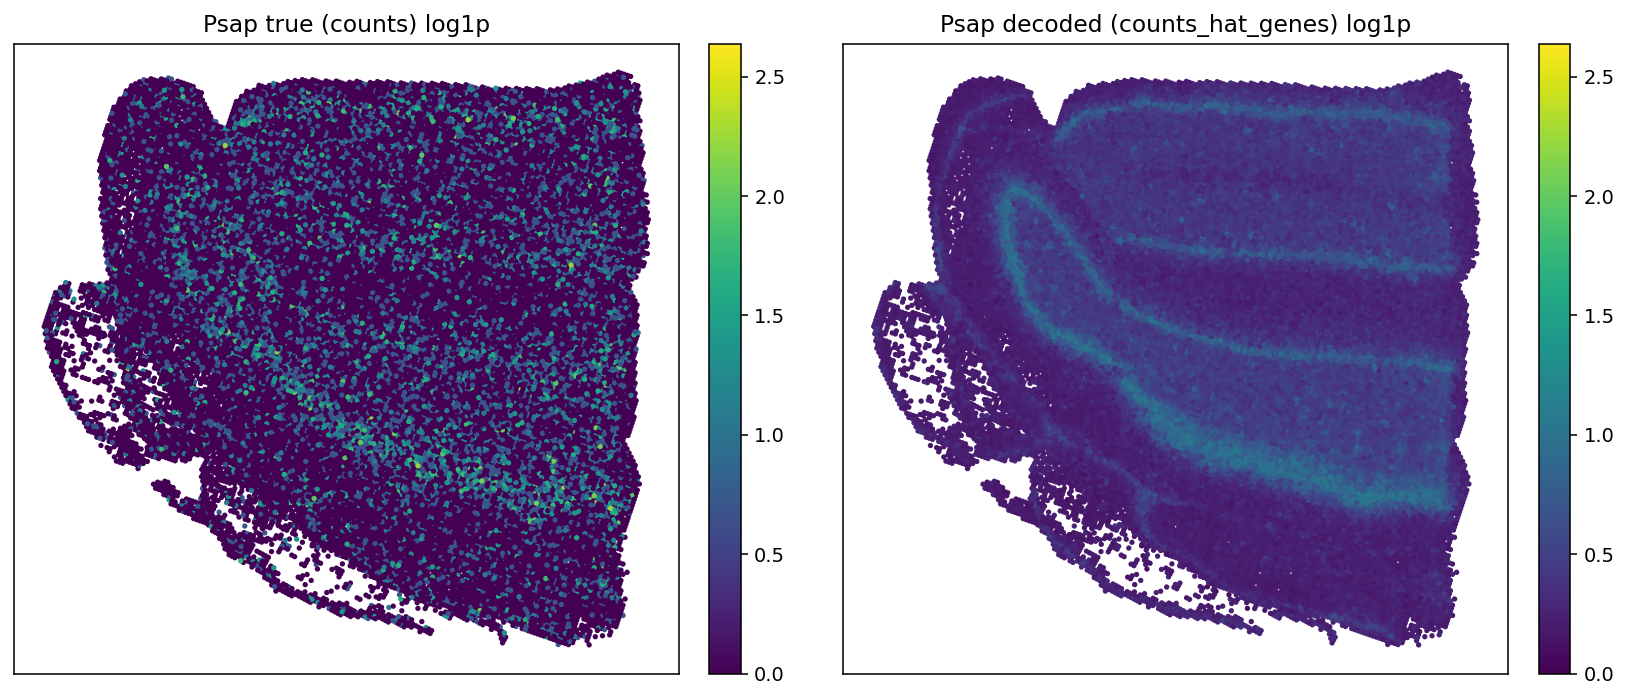

In [8]:
PAIR = "T167_T168"
ckpt_path = f"{OUT_DIR}/decoder_counts_pair_{PAIR}.pt"
stat_path = f"{OUT_DIR}/decoder_counts_pair_{PAIR}.json"

device = "cuda:0"
decoder, pred_genes, meta = load_count_decoder(ckpt_path, stat_path, device=device)

#  pair ()
mask = adata.obs["sample"].astype(str).isin(PAIR.split("_")).values
adata_pair = adata[mask].copy()

#  obsm
decode_adata_to_obsm(
    adata_pair, model, decoder,
    out_key="counts_hat_genes",
    latent_key="X_scanVI",   # missing get_latent_representation
    batch_size=4096,
    device=device,
    clamp_nonneg=True,
)
adata_pair.uns["counts_hat_genes_var"] = pred_genes

# gene: vs 
gene = "Psap"
fig, _ = plot_true_vs_pred_spatial(
    adata_pair,
    gene,
    true_layer="counts",
    pred_obsm="counts_hat_genes",
    pred_genes=pred_genes,
    x="cx_aligned", y="cy_aligned",
    log1p=True,
    same_scale=True,
)
plt.show()